In [3]:
from typing import Annotated
from dotenv import load_dotenv
load_dotenv()

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [4]:
from langchain.chat_models import init_chat_model

In [5]:
llm = init_chat_model("google_genai:gemini-2.0-flash")

class State(TypedDict):
    messages: Annotated[list, add_messages]

def chatbot(state: State) -> State:
    return {"messages": [llm.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("chatbot_node", chatbot)

builder.add_edge(START, "chatbot_node")
builder.add_edge("chatbot_node", END)

graph = builder.compile()

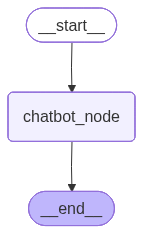

In [6]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
message = {"role": "user", "content": "Who walked on the moon for the first time? Print only the name"}
# message = {"role": "user", "content": "What is the latest price of MSFT stock?"}
response = graph.invoke({"messages":[message]})

response["messages"]

[HumanMessage(content='Who walked on the moon for the first time? Print only the name', additional_kwargs={}, response_metadata={}, id='e36d4907-58bb-44b9-a451-edf6ee63f453'),
 AIMessage(content='Neil Armstrong', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--2c508a41-763d-46a5-acf1-e17e0d66b2dd-0', usage_metadata={'input_tokens': 14, 'output_tokens': 3, 'total_tokens': 17, 'input_token_details': {'cache_read': 0}})]

In [8]:
state = None
while True:
    in_message = input("You: ")
    if in_message.lower() in {"quit","exit"}:
        break
    if state is None:
        state: State = {
            "messages": [{"role": "user", "content": in_message}]
        }
    else:
        state["messages"].append({"role": "user", "content": in_message})

    state = graph.invoke(state)
    print("Bot:", state["messages"][-1].content)

Bot: Hi there! How can I help you today?


/Users/a62086/Downloads/SaraChoudhary/GitPush/MY-Work---Personal/LangGraph/.venv/lib/python3.13/site-packages/langchain_google_genai/chat_models.py:1568: UserWarning: HumanMessage with empty content was removed to prevent API error
  warnings.warn(


Bot: 


/Users/a62086/Downloads/SaraChoudhary/GitPush/MY-Work---Personal/LangGraph/.venv/lib/python3.13/site-packages/langchain_google_genai/chat_models.py:1568: UserWarning: HumanMessage with empty content was removed to prevent API error
  warnings.warn(


Bot: Okay, I'm ready. What can I do for you? Do you have any questions you want to ask, or is there anything specific you'd like to talk about?


/Users/a62086/Downloads/SaraChoudhary/GitPush/MY-Work---Personal/LangGraph/.venv/lib/python3.13/site-packages/langchain_google_genai/chat_models.py:1568: UserWarning: HumanMessage with empty content was removed to prevent API error
  warnings.warn(


Bot: 


KeyboardInterrupt: Interrupted by user